# Notebook 4: Feature Engineering and Preparation

This notebook prepares features for modeling, including correlation analysis and feature selection to identify the most informative variables for AMR prediction.

---


In [2]:
from pathlib import Path
import re

# Extract genome IDs from filenames
amr_file_ids = set()
for f in Path("../amr_results/").glob("*.tsv"):
    # Extract the ID from filename (adjust regex based on your naming)
    match = re.search(r'(\d+(?:\.\d+)?)', f.stem)
    print(match)
    if match:
        amr_file_ids.add(float(match.group(1)))

# Compare with phenotype data
phenotype_ids = set(df['Genome ID'].unique())

print(f"AMR file IDs found: {len(amr_file_ids)}")
print(f"In both: {len(amr_file_ids & phenotype_ids)}")
print(f"Only in phenotype: {len(phenotype_ids - amr_file_ids)}")

<re.Match object; span=(0, 9), match='562.17621'>
<re.Match object; span=(0, 9), match='562.23396'>
<re.Match object; span=(0, 9), match='562.42783'>
<re.Match object; span=(0, 9), match='562.99193'>
<re.Match object; span=(0, 9), match='562.98925'>
<re.Match object; span=(0, 8), match='562.7767'>
<re.Match object; span=(0, 8), match='562.7773'>
<re.Match object; span=(0, 9), match='562.98919'>
<re.Match object; span=(0, 8), match='562.7766'>
<re.Match object; span=(0, 8), match='562.9978'>
<re.Match object; span=(0, 10), match='562.100372'>
<re.Match object; span=(0, 9), match='562.22923'>
<re.Match object; span=(0, 9), match='562.42755'>
<re.Match object; span=(0, 9), match='562.19631'>
<re.Match object; span=(0, 10), match='562.140839'>
<re.Match object; span=(0, 9), match='562.22466'>
<re.Match object; span=(0, 10), match='562.145002'>
<re.Match object; span=(0, 9), match='562.97022'>
<re.Match object; span=(0, 9), match='562.99147'>
<re.Match object; span=(0, 10), match='562.14425

NameError: name 'df' is not defined

In [3]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import matthews_corrcoef, roc_auc_score
import joblib
from pathlib import Path

# =============================================================================
# STEP 2: Build gene-presence matrix from AMRFinder outputs
# =============================================================================

def build_amr_features(amr_folder_path):
    """
    Loop through all _amr.tsv files and create binary gene presence matrix
    Input: folder containing 562.144628_amr.tsv, 562.5691_amr.tsv, etc.
    Output: ../data/processed/amr_features.csv with Genome ID and gene_* columns (0/1)
    """
    amr_files = list(Path(amr_folder_path).glob("*.tsv")) # Adjusted glob pattern as filenames are e.g., '562.144628.tsv'
    all_genes = set()
    genome_genes = {}

    print(f"Processing {len(amr_files)} AMRFinder files...")

    for amr_file in amr_files:
        # Extract Genome ID from filename (e.g., "562.144628.tsv" -> "562.144628")
        genome_id = str(amr_file.stem).replace('_amr', '')

        try:
            # Read AMRFinder output
            df = pd.read_csv(amr_file, sep='\t')

            # Corrected: Use 'Gene symbol' instead of 'NAME'
            if 'Gene symbol' in df.columns and not df['Gene symbol'].empty:
                genes = set(df['Gene symbol'].dropna().unique())
                genome_genes[float(genome_id)] = list(genes) # Convert to float for consistency
                all_genes.update(genes)
            else:
                genome_genes[float(genome_id)] = []

        except pd.errors.EmptyDataError:
            print(f"Warning: {amr_file.name} is empty. Skipping.")
            genome_genes[float(genome_id)] = []
        except KeyError:
            print(f"Warning: 'Gene symbol' column not found in {amr_file.name}. Skipping gene extraction for this file.")
            genome_genes[float(genome_id)] = []
        except ValueError:
            print(f"Warning: Could not convert genome ID '{genome_id}' from file {amr_file.name} to float. Skipping.")
            continue # Skip to the next file if ID conversion fails
        except Exception as e:
            print(f"An unexpected error occurred while processing {amr_file}: {e}")
            continue

    print(f"Found {len(all_genes)} unique AMR genes across all genomes")

    # Create binary matrix
    genes_list = sorted(list(all_genes))
    feature_matrix = []

    for genome_id, genes_in_genome in genome_genes.items():
        row = [genome_id] + [1 if gene in genes_in_genome else 0 for gene in genes_list]
        feature_matrix.append(row)

    # Create DataFrame
    columns = ['Genome ID'] + [f'gene_{gene}' for gene in genes_list] # Corrected to 'Genome ID'
    amr_features = pd.DataFrame(feature_matrix, columns=columns)

    # Save
    amr_features.to_csv('../data/processed/amr_features.csv', index=False)
    print("Saved ../data/processed/amr_features.csv")
    return amr_features

# =============================================================================
# STEP 3: Merge phenotype data with gene features
# =============================================================================

def create_antibiotic_datasets(refined_data_path, amr_features_path):
    """
    Create separate datasets for each antibiotic by merging phenotypes + features
    Output: gent_df.csv, cip_df.csv, mero_df.csv
    """
    # Load data
    refined_data = pd.read_csv(refined_data_path)
    amr_features = pd.read_csv(amr_features_path)

    antibiotics = ['gentamicin', 'ciprofloxacin', 'meropenem']
    datasets = {}

    for antibiotic in antibiotics:
        print(f"\nProcessing {antibiotic}...")

        # Filter phenotypes for this antibiotic
        antibiotic_data = refined_data[refined_data['Antibiotic'] == antibiotic].copy()
        print(f"Found {len(antibiotic_data)} phenotype records for {antibiotic}")

        # Merge with AMRFinder features
        dataset = antibiotic_data.merge(amr_features, on='Genome ID', how='inner') # Corrected to 'Genome ID'
        print(f"After merge: {len(dataset)} genomes with both phenotype + features")

        # Filter out 'Intermediate' phenotypes, keeping only 'Resistant' and 'Susceptible'.
        dataset = dataset[
            dataset['Resistant Phenotype'].isin(['Resistant', 'Susceptible'])
        ].copy()

        if dataset.empty:
            print(f"No data for {antibiotic} after filtering for R/S. Skipping.")
            continue

        # Convert the 'Resistant Phenotype' column into a binary numerical target variable
        dataset['Resistant_Binary'] = dataset['Resistant Phenotype'].apply(
            lambda x: 1 if x == 'Resistant' else 0
        )

        # Save
        dataset.to_csv(f'../data/features/{antibiotic}_df.csv', index=False)
        datasets[antibiotic] = dataset
        print(f"Saved ../data/features/{antibiotic}_df.csv")

    return datasets

# =============================================================================
# STEP 4-5: Train models per antibiotic
# =============================================================================

def train_models(datasets):
    """
    Train RandomForest model for each antibiotic dataset
    Saves: model, label_encoder, feature_cols for each antibiotic
    """
    antibiotics = list(datasets.keys())
    results = {}

    for antibiotic in antibiotics:
        df = datasets[antibiotic]

        # Define features (all gene_* columns)
        feature_cols = [col for col in df.columns if col.startswith('gene_')]
        X = df[feature_cols]
        y = df['Resistant_Binary']  # Changed to the binary target

        print(f"\nTraining {antibiotic} model...")
        print(f"Features: {len(feature_cols)}, Samples: {len(df)}")
        print(f"Class distribution:\n{y.value_counts()}")

        # Encode labels (not strictly needed for binary 0/1, but good practice if more classes were involved originally)
        # le = LabelEncoder()
        # y_encoded = le.fit_transform(y)
        y_encoded = y # Use the already binary column directly

        # Train/test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
        )

        # Train RandomForest
        model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        model.fit(X_train, y_train)

        # Predictions
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)

        # Metrics
        mcc = matthews_corrcoef(y_test, y_pred)
        # Corrected: Pass only probabilities of the positive class for binary AUC
        auc = roc_auc_score(y_test, y_proba[:, 1])

        print(f"MCC: {mcc:.3f}, AUC: {auc:.3f}")

        # Save model bundle to  for easy access
        joblib.dump({
            'model': model,
            'label_encoder': {0: 'Susceptible', 1: 'Resistant'}, # Manually define labels for binary case
            'feature_cols': feature_cols
        }, f'../models/{antibiotic}_model_bundle.pkl') # Save to 

        results[antibiotic] = {
            'mcc': mcc,
            'auc': auc,
            'feature_importance': pd.DataFrame({
                'gene': feature_cols,
                'importance': model.feature_importances_
            }).sort_values('importance', ascending=False).head(10)
        }

    return results

# =============================================================================
# STEP 6: Prediction function for new genome
# =============================================================================

def predict_new_genome(amr_tsv_path, model_bundles):
    """
    Predict resistance for a single new genome's AMRFinder output
    Input: path to new_genome_amr.tsv
    Output: dict with predictions for all 3 antibiotics
    """
    # Load and process new AMRFinder output (same as Step 2 logic)
    df = pd.read_csv(amr_tsv_path, sep='\t')
    genes_present = set(df['Gene symbol'].dropna().unique()) # Corrected to 'Gene symbol'

    predictions = {}

    for antibiotic, bundle_path in model_bundles.items():
        # Load model bundle
        bundle = joblib.load(bundle_path)
        model = bundle['model']
        feature_cols = bundle['feature_cols']
        # le = bundle['label_encoder'] # LabelEncoder not directly used in this modified binary context
        le_classes = list(bundle['label_encoder'].values()) # Extract classes for dictionary

        # Create feature vector (same order as training)
        # Ensure the feature vector has the same number of features as the trained model
        feature_vector_dict = {col: (1 if col.replace('gene_', '') in genes_present else 0) for col in feature_cols}
        feature_vector = pd.DataFrame([feature_vector_dict])

        # Predict
        proba = model.predict_proba(feature_vector)[0]
        pred_class_encoded = model.predict(feature_vector)[0]
        # Map encoded prediction back to original label using the stored mapping
        pred_class = le_classes[pred_class_encoded] # Map 0/1 to 'Susceptible'/'Resistant'
        confidence = np.max(proba)

        predictions[antibiotic] = {
            'prediction': pred_class,
            'confidence': confidence,
            'probabilities': dict(zip(le_classes, proba)) # Use le_classes for probability labels
        }

    return predictions

# =============================================================================
# MAIN EXECUTION - Run all steps
# =============================================================================

if __name__ == "__main__":
    # Step 1: Update these paths to your files
    AMR_FOLDER = "../amr_results"  # Corrected path to folder with TSV files
    REFINED_DATA_PATH = "../data/processed/refined_data.csv"  # Corrected path to phenotype table

    # Step 2: Build features
    print("=== STEP 2: Building AMR feature matrix ===")
    amr_features = build_amr_features(AMR_FOLDER)

    # Step 3: Create antibiotic datasets
    print("\n=== STEP 3: Creating antibiotic datasets ===")
    datasets = create_antibiotic_datasets(REFINED_DATA_PATH, '../data/processed/amr_features.csv')

    # Steps 4-5: Train models
    print("\n=== STEPS 4-5: Training models ===")
    results = train_models(datasets)

    # Print results summary
    print("\n=== FINAL RESULTS ===")
    for antibiotic, metrics in results.items():
        print(f"{antibiotic}: AUC={metrics['auc']:.3f}, MCC={metrics['mcc']:.3f}")
        print("Top 5 important genes:")
        print(metrics['feature_importance'].head())
        print()

    print("\u2705 All steps complete!")
    print("Files created:")
    print("- ../data/processed/amr_features.csv")
    print("- ../data/features/gentamicin_df.csv, ../data/features/ciprofloxacin_df.csv, ../data/features/meropenem_df.csv")
    print("- ../models/*_model_bundle.pkl (for predictions)")

=== STEP 2: Building AMR feature matrix ===
Processing 274 AMRFinder files...
Found 311 unique AMR genes across all genomes
Saved ../data/processed/amr_features.csv

=== STEP 3: Creating antibiotic datasets ===

Processing gentamicin...
Found 7878 phenotype records for gentamicin
After merge: 277 genomes with both phenotype + features
Saved ../data/features/gentamicin_df.csv

Processing ciprofloxacin...
Found 7749 phenotype records for ciprofloxacin
After merge: 269 genomes with both phenotype + features
Saved ../data/features/ciprofloxacin_df.csv

Processing meropenem...
Found 6140 phenotype records for meropenem
After merge: 240 genomes with both phenotype + features
Saved ../data/features/meropenem_df.csv

=== STEPS 4-5: Training models ===

Training gentamicin model...
Features: 311, Samples: 277
Class distribution:
Resistant_Binary
0    199
1     78
Name: count, dtype: int64
MCC: 0.913, AUC: 0.997

Training ciprofloxacin model...
Features: 311, Samples: 266
Class distribution:
Res

Generating Correlation Matrix Heatmaps for Gene Features...


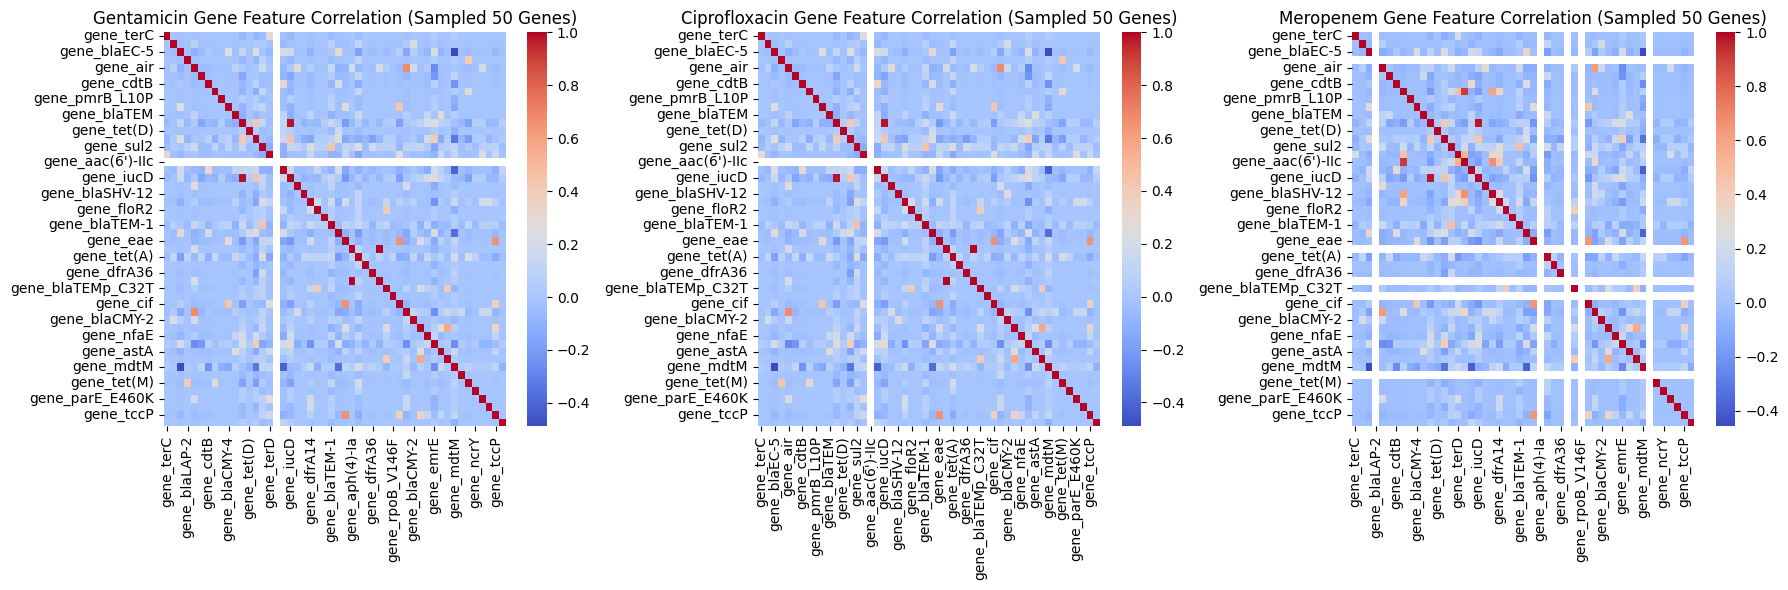

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# List of antibiotics for which we have dataframes
antibiotics = ['gentamicin', 'ciprofloxacin', 'meropenem']

print("Generating Correlation Matrix Heatmaps for Gene Features...")

plt.figure(figsize=(18, 6))

for i, antibiotic in enumerate(antibiotics):
    df_path = f'../data/features/{antibiotic}_df.csv'
    try:
        df_antibiotic = pd.read_csv(df_path)

        # Select only gene feature columns for correlation matrix
        gene_cols = [col for col in df_antibiotic.columns if col.startswith('gene_')]
        if not gene_cols:
            print(f"No gene features found for {antibiotic}. Skipping correlation matrix.")
            continue

        # Compute the correlation matrix. Using a subset of genes for visual clarity if there are too many.
        # Let's take a sample of 50 genes if there are more than 50, otherwise use all.
        if len(gene_cols) > 50:
            sampled_gene_cols = pd.Series(gene_cols).sample(50, random_state=42).tolist()
            correlation_matrix = df_antibiotic[sampled_gene_cols].corr()
            title_suffix = " (Sampled 50 Genes)"
        else:
            correlation_matrix = df_antibiotic[gene_cols].corr()
            title_suffix = ""

        plt.subplot(1, 3, i + 1)
        sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False, fmt=".2f", cbar=True)
        plt.title(f'{antibiotic.capitalize()} Gene Feature Correlation{title_suffix}')
        plt.tight_layout()

    except FileNotFoundError:
        print(f"Error: {df_path} not found. Skipping {antibiotic}.")
    except Exception as e:
        print(f"An error occurred processing {antibiotic}: {e}")

plt.show()

### Explanation of Correlation Matrix Heatmaps:

These heatmaps visualize the pairwise correlation between the gene features for each antibiotic.

*   **Color Scale (Coolwarm)**: Red colors indicate a positive correlation, blue colors indicate a negative correlation, and white/light colors indicate little to no correlation. Darker shades mean stronger correlation.
*   **Interpretation**: In an AMR context, highly correlated genes might suggest they often co-occur or are part of the same resistance mechanism. Negative correlations are less common but could point to genes that are rarely found together.

Since there are many genes, a sample of up to 50 genes was taken for each heatmap to ensure readability. If an antibiotic had fewer than 50 genes, all available genes were used.